# Credit Risk Modelling — Part 4.4: Logistic Regression
---
**Objective:** Train and evaluate a Logistic Regression model as the first learned baseline.

Logistic Regression is the workhorse of credit scoring — it is fast, interpretable, and often surprisingly competitive. It also gives us **signed coefficients**, meaning we can directly read which features push the default probability up or down.

**Why start with LR before tree models?**
- Establishes a **linear baseline** — if a non-linear model barely beats it, the extra complexity isn't justified
- Coefficients are directly interpretable — regulators often require this
- Very fast to train and cross-validate
- Works well with the `StandardScaler` pipeline

**Steps:**
1. Load data & framework from 4.1 / 4.2
2. Build the LR pipeline (StandardScaler + LogisticRegression)
3. Hyperparameter rationale
4. Train the model
5. Cross-validation (5-fold stratified)
6. Compute all evaluation metrics
7. Full 6-panel dashboard
8. Coefficient analysis — which features matter most and in which direction
9. Compare against bureau score baseline
10. Save result

## 1 — Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
GRAY = "#9E9E9E"

# Load arrays from Part 4.1
X_train        = np.load("X_train.npy")
X_test         = np.load("X_test.npy")
y_train        = np.load("y_train.npy")
y_test         = np.load("y_test.npy")
sample_weights = np.load("sample_weights.npy")
meta           = joblib.load("preprocessing_meta.pkl")
CV             = joblib.load("cv_strategy.pkl")
with open("metric_reference.json") as f:
    metric_ref = json.load(f)

MODEL_NAME  = "Logistic Regression"
MODEL_COLOR = metric_ref["model_colors"][MODEL_NAME]

# Load bureau score benchmark from Part 4.3
results = joblib.load("results_so_far.pkl")
bureau_auc = results["Bureau Score (score_1)"]["test_auc"]

feature_cols = meta["feature_cols_final"]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Bureau score benchmark AUC : {bureau_auc:.4f}  (we must beat this)")
print("✓ Loaded")

X_train : (28397, 198)
X_test  : (4000, 198)
Bureau score benchmark AUC : 0.8152  (we must beat this)
✓ Loaded


---
## 2 — Hyperparameter Choices & Rationale

| Parameter | Value | Why |
|---|---|---|
| `C` | `0.05` | Strong regularisation — 198 features, some noisy; prevents overfitting |
| `penalty` | `l2` | Ridge regularisation — shrinks all coefficients, keeps all features in model |
| `solver` | `saga` | Handles large datasets and L2 efficiently; supports `class_weight` |
| `class_weight` | `balanced` | Automatically weights defaults by 16.3× — handles imbalance without manual weights |
| `max_iter` | `1000` | Enough iterations to guarantee convergence on 198 features |
| `random_state` | `42` | Reproducibility |
| `StandardScaler` | applied | LR is sensitive to feature scale — we must normalise before fitting |

> **Note on `class_weight='balanced'` vs `sample_weight`:**  
> For LR in a sklearn Pipeline, `class_weight='balanced'` is cleaner than passing `sample_weight` to `.fit()` — it applies the same correction internally and works seamlessly with cross-validation.

## 3 — Build the Pipeline

In [2]:
# StandardScaler inside pipeline ensures:
# 1. Scaler is fit ONLY on training fold during CV (no leakage)
# 2. Same scaler is applied to test set automatically
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        C            = 0.05,
        penalty      = "l2",
        solver       = "saga",
        class_weight = "balanced",
        max_iter     = 1000,
        random_state = 42,
        n_jobs       = -1
    ))
])

print("Pipeline architecture:")
print("  Input: X_train (28397 x 198, float32)")
print("  Step 1 — StandardScaler")
print("           Subtracts mean, divides by std per feature")
print("           Fit on train only — applied to test identically")
print("  Step 2 — LogisticRegression")
print("           C=0.05 (strong L2 regularisation)")
print("           class_weight='balanced' (handles 16.3:1 imbalance)")
print("           solver='saga' (fast for large datasets)")
print("  Output: P(default) in [0, 1]")

Pipeline architecture:
  Input: X_train (28397 x 198, float32)
  Step 1 — StandardScaler
           Subtracts mean, divides by std per feature
           Fit on train only — applied to test identically
  Step 2 — LogisticRegression
           C=0.05 (strong L2 regularisation)
           class_weight='balanced' (handles 16.3:1 imbalance)
           solver='saga' (fast for large datasets)
  Output: P(default) in [0, 1]


## 4 — Train the Model

In [3]:
import time

print("Training Logistic Regression...")
t0 = time.time()
lr_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

print(f"✓ Training complete in {train_time:.1f}s")
print()

# Check convergence
clf = lr_pipeline.named_steps["clf"]
print(f"Solver iterations used : {clf.n_iter_[0]}")
print(f"Max iterations allowed : {clf.max_iter}")
converged = clf.n_iter_[0] < clf.max_iter
print(f"Converged              : {'✓ Yes' if converged else '✗ No — increase max_iter'}")
print()
print(f"Coefficient shape      : {clf.coef_.shape}  (1 row x {clf.coef_.shape[1]} features)")
print(f"Intercept              : {clf.intercept_[0]:.4f}")

Training Logistic Regression...
✓ Training complete in 39.9s

Solver iterations used : 952
Max iterations allowed : 1000
Converged              : ✓ Yes

Coefficient shape      : (1, 198)  (1 row x 198 features)
Intercept              : -1.6095


---
## 5 — Cross-Validation (5-Fold Stratified)

Cross-validation tells us whether the model **generalises** or is overfit to the training set.  
We use the same `CV` object defined in Part 4.2 so all models use identical fold splits.

In [4]:
print("Running 5-fold stratified cross-validation...")
print("(This evaluates the full pipeline including StandardScaler per fold)")
print()

t0 = time.time()
cv_scores = cross_val_score(
    lr_pipeline, X_train, y_train,
    cv      = CV,
    scoring = "roc_auc",
    n_jobs  = -1
)
cv_time = time.time() - t0

print(f"CV complete in {cv_time:.1f}s")
print()
print(f"{'Fold':<8} {'AUC':>10}")
print("-" * 20)
for i, score in enumerate(cv_scores, 1):
    print(f"  {i:<6} {score:>10.4f}")
print("-" * 20)
print(f"  {'Mean':<6} {cv_scores.mean():>10.4f}")
print(f"  {'Std':<6} {cv_scores.std():>10.4f}")
print()

overfit_gap = None
# We'll compare test AUC to CV AUC after computing test metrics

Running 5-fold stratified cross-validation...
(This evaluates the full pipeline including StandardScaler per fold)



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV complete in 67.1s

Fold            AUC
--------------------
  1          0.8430
  2          0.8419
  3          0.8512
  4          0.8501
  5          0.8463
--------------------
  Mean       0.8465
  Std        0.0037



---
## 6 — Compute All Test Set Metrics

In [5]:
# Helper: KS statistic
def ks_statistic(y_true, y_proba):
    df = pd.DataFrame({"y": y_true, "p": y_proba}).sort_values("p")
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    df["cum_pos"] = (df["y"] == 1).cumsum() / n_pos
    df["cum_neg"] = (df["y"] == 0).cumsum() / n_neg
    df["ks"]      = (df["cum_neg"] - df["cum_pos"]).abs()
    return df["ks"].max(), df.loc[df["ks"].idxmax(), "p"], df

# Predictions
proba_test = lr_pipeline.predict_proba(X_test)[:, 1]
proba_train = lr_pipeline.predict_proba(X_train)[:, 1]

# Metrics
test_auc  = roc_auc_score(y_test, proba_test)
test_ap   = average_precision_score(y_test, proba_test)
gini      = 2 * test_auc - 1
ks_val, ks_thresh, ks_df = ks_statistic(y_test, proba_test)
train_auc = roc_auc_score(y_train, proba_train)

# Optimal threshold
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_test, proba_test)
j_idx      = np.argmax(tpr_arr - fpr_arr)
opt_thresh = float(thresh_arr[j_idx])
y_pred_opt = (proba_test >= opt_thresh).astype(int)

print("=" * 52)
print(f"  LOGISTIC REGRESSION — TEST SET RESULTS")
print("=" * 52)
print(f"  {'Metric':<35} {'Value':>10}")
print(f"  {'-'*47}")
print(f"  {'Test ROC-AUC':<35} {test_auc:>10.4f}")
print(f"  {'Train ROC-AUC (overfit check)':<35} {train_auc:>10.4f}")
print(f"  {'Test Avg Precision (AP)':<35} {test_ap:>10.4f}")
print(f"  {'Gini Coefficient':<35} {gini:>10.4f}")
print(f"  {'KS Statistic':<35} {ks_val:>10.4f}")
print(f"  {'Optimal Threshold (Youden J)':<35} {opt_thresh:>10.4f}")
print(f"  {'CV AUC mean':<35} {cv_scores.mean():>10.4f}")
print(f"  {'CV AUC std':<35} {cv_scores.std():>10.4f}")
print(f"  {'Overfit gap (train - CV mean)':<35} {train_auc - cv_scores.mean():>10.4f}")
print()
print(f"  vs Bureau Score baseline (AUC={bureau_auc:.4f}):")
delta = test_auc - bureau_auc
icon  = "✓ BEATS" if delta > 0 else "✗ BELOW"
print(f"  {icon} baseline by {delta:+.4f}")

  LOGISTIC REGRESSION — TEST SET RESULTS
  Metric                                   Value
  -----------------------------------------------
  Test ROC-AUC                            0.8575
  Train ROC-AUC (overfit check)           0.8651
  Test Avg Precision (AP)                 0.2397
  Gini Coefficient                        0.7149
  KS Statistic                            0.5938
  Optimal Threshold (Youden J)            0.5463
  CV AUC mean                             0.8465
  CV AUC std                              0.0037
  Overfit gap (train - CV mean)           0.0186

  vs Bureau Score baseline (AUC=0.8152):
  ✓ BEATS baseline by +0.0423


## 7 — Classification Report

In [6]:
print(f"Classification Report (threshold = {opt_thresh:.4f}):")
print(classification_report(y_test, y_pred_opt,
                            target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
print(f"Business interpretation:")
print(f"  True  Negatives (correctly approved safe)  : {tn:>5,}")
print(f"  False Positives (safe rejected incorrectly) : {fp:>5,}  <- customer friction")
print(f"  False Negatives (defaults we missed)        : {fn:>5,}  <- credit loss risk")
print(f"  True  Positives (defaults caught)           : {tp:>5,}  <- value delivered")
print()
print(f"  Default recall (sensitivity): {tp/(tp+fn)*100:.1f}%")
print(f"  Default precision           : {tp/(tp+fp)*100:.1f}%")

Classification Report (threshold = 0.5463):
              precision    recall  f1-score   support

  No Default       0.99      0.76      0.86      3766
     Default       0.18      0.83      0.29       234

    accuracy                           0.76      4000
   macro avg       0.58      0.80      0.58      4000
weighted avg       0.94      0.76      0.83      4000

Business interpretation:
  True  Negatives (correctly approved safe)  : 2,864
  False Positives (safe rejected incorrectly) :   902  <- customer friction
  False Negatives (defaults we missed)        :    39  <- credit loss risk
  True  Positives (defaults caught)           :   195  <- value delivered

  Default recall (sensitivity): 83.3%
  Default precision           : 17.8%


---
## 8 — Evaluation Dashboard

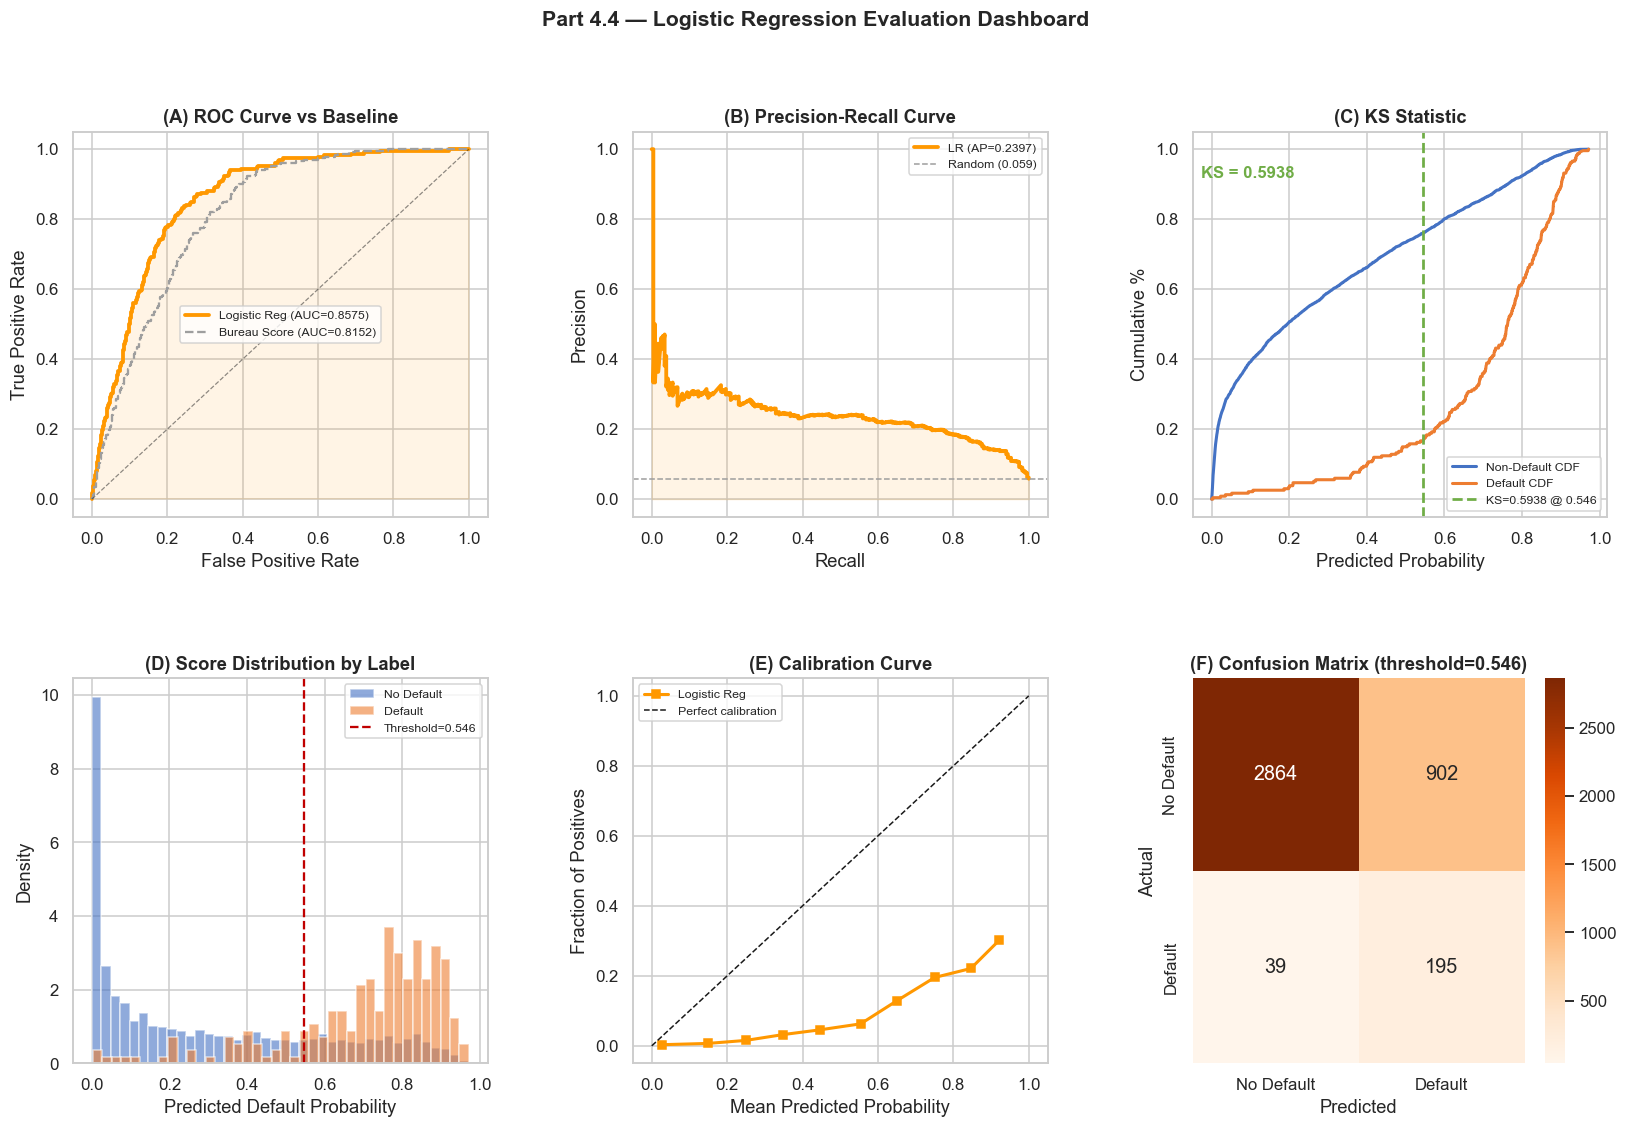

In [7]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Part 4.4 — Logistic Regression Evaluation Dashboard",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# (A) ROC Curve — LR vs Bureau Score
ax = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, proba_test)
ax.plot(fpr, tpr, color=MODEL_COLOR, lw=2.5,
        label=f"Logistic Reg (AUC={test_auc:.4f})")
ax.fill_between(fpr, tpr, alpha=0.10, color=MODEL_COLOR)
# Overlay bureau score
bureau_proba = np.load("score1_proba_test.npy")
fpr_b, tpr_b, _ = roc_curve(y_test, bureau_proba)
ax.plot(fpr_b, tpr_b, color=GRAY, lw=1.5, linestyle="--",
        label=f"Bureau Score (AUC={bureau_auc:.4f})")
ax.plot([0,1],[0,1], "k--", lw=0.8, alpha=0.5)
ax.set_title("(A) ROC Curve vs Baseline", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)

# (B) Precision-Recall Curve
ax = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y_test, proba_test)
baseline = y_test.mean()
ax.plot(rec, prec, color=MODEL_COLOR, lw=2.5,
        label=f"LR (AP={test_ap:.4f})")
ax.fill_between(rec, prec, alpha=0.10, color=MODEL_COLOR)
ax.axhline(baseline, color=GRAY, linestyle="--", lw=1,
           label=f"Random ({baseline:.3f})")
ax.set_title("(B) Precision-Recall Curve", fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=8)

# (C) KS Statistic
ax = fig.add_subplot(gs[0, 2])
ax.plot(ks_df["p"], ks_df["cum_neg"], color=BLUE,   lw=2, label="Non-Default CDF")
ax.plot(ks_df["p"], ks_df["cum_pos"], color=ORANGE, lw=2, label="Default CDF")
ax.axvline(ks_thresh, color=GREEN, linestyle="--", lw=1.8,
           label=f"KS={ks_val:.4f} @ {ks_thresh:.3f}")
ax.set_title("(C) KS Statistic", fontweight="bold")
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Cumulative %")
ax.legend(fontsize=8)
ax.text(0.02, 0.88, f"KS = {ks_val:.4f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color=GREEN)

# (D) Score distribution by label
ax = fig.add_subplot(gs[1, 0])
for lbl, c, nm in [(0, BLUE, "No Default"), (1, ORANGE, "Default")]:
    ax.hist(proba_test[y_test==lbl], bins=40, alpha=0.60,
            color=c, density=True, label=nm)
ax.axvline(opt_thresh, color=RED, linestyle="--", lw=1.5,
           label=f"Threshold={opt_thresh:.3f}")
ax.set_title("(D) Score Distribution by Label", fontweight="bold")
ax.set_xlabel("Predicted Default Probability"); ax.set_ylabel("Density")
ax.legend(fontsize=8)

# (E) Calibration curve
ax = fig.add_subplot(gs[1, 1])
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
ax.plot(prob_pred, prob_true, "s-", color=MODEL_COLOR, lw=2,
        label="Logistic Reg", markersize=5)
ax.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
ax.set_title("(E) Calibration Curve", fontweight="bold")
ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
ax.legend(fontsize=8)

# (F) Confusion Matrix
ax = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax,
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"],
            annot_kws={"size": 13})
ax.set_title(f"(F) Confusion Matrix (threshold={opt_thresh:.3f})", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

---
## 9 — Coefficient Analysis

One of LR's biggest advantages over tree models is **signed interpretable coefficients**.  
Each coefficient tells us:
- **Direction** (+/-): does the feature increase or decrease default probability?
- **Magnitude**: how strongly does it push the prediction?

After `StandardScaler`, all coefficients are on the same scale — so magnitude is comparable.

In [8]:
# Extract coefficients from pipeline
scaler = lr_pipeline.named_steps["scaler"]
clf    = lr_pipeline.named_steps["clf"]

coef = clf.coef_[0]   # shape: (n_features,)
coef_df = pd.DataFrame({
    "feature"    : feature_cols,
    "coefficient": coef
}).sort_values("coefficient", key=abs, ascending=False)

# Split by direction
coef_pos = coef_df[coef_df["coefficient"] > 0].head(20)  # top risk-increasing
coef_neg = coef_df[coef_df["coefficient"] < 0].head(20)  # top risk-decreasing

print("Top 10 features INCREASING default risk (positive coeff):")
print(coef_pos[["feature","coefficient"]].head(10).to_string(index=False))
print()
print("Top 10 features DECREASING default risk (negative coeff):")
print(coef_neg[["feature","coefficient"]].head(10).to_string(index=False))

Top 10 features INCREASING default risk (positive coeff):
                        feature  coefficient
           repayment_history_26     0.284539
      credit_limit_3_is_missing     0.264680
           balance_8_is_missing     0.244161
           balance_1_is_missing     0.244161
       utilization_2_is_missing     0.238227
                 utilization_16     0.217949
                     balance_20     0.215778
           recency_1_is_missing     0.212326
repayment_history_29_is_missing     0.190587
                  utilization_2     0.188548

Top 10 features DECREASING default risk (negative coeff):
                  feature  coefficient
                  score_1    -0.926088
                recency_1    -0.496025
    balance_11_is_missing    -0.246421
        spend_behaviour_4    -0.245735
                balance_8    -0.240313
           utilization_12    -0.232545
utilization_11_is_missing    -0.228806
utilization_15_is_missing    -0.225040
 utilization_8_is_missing    -0.22504

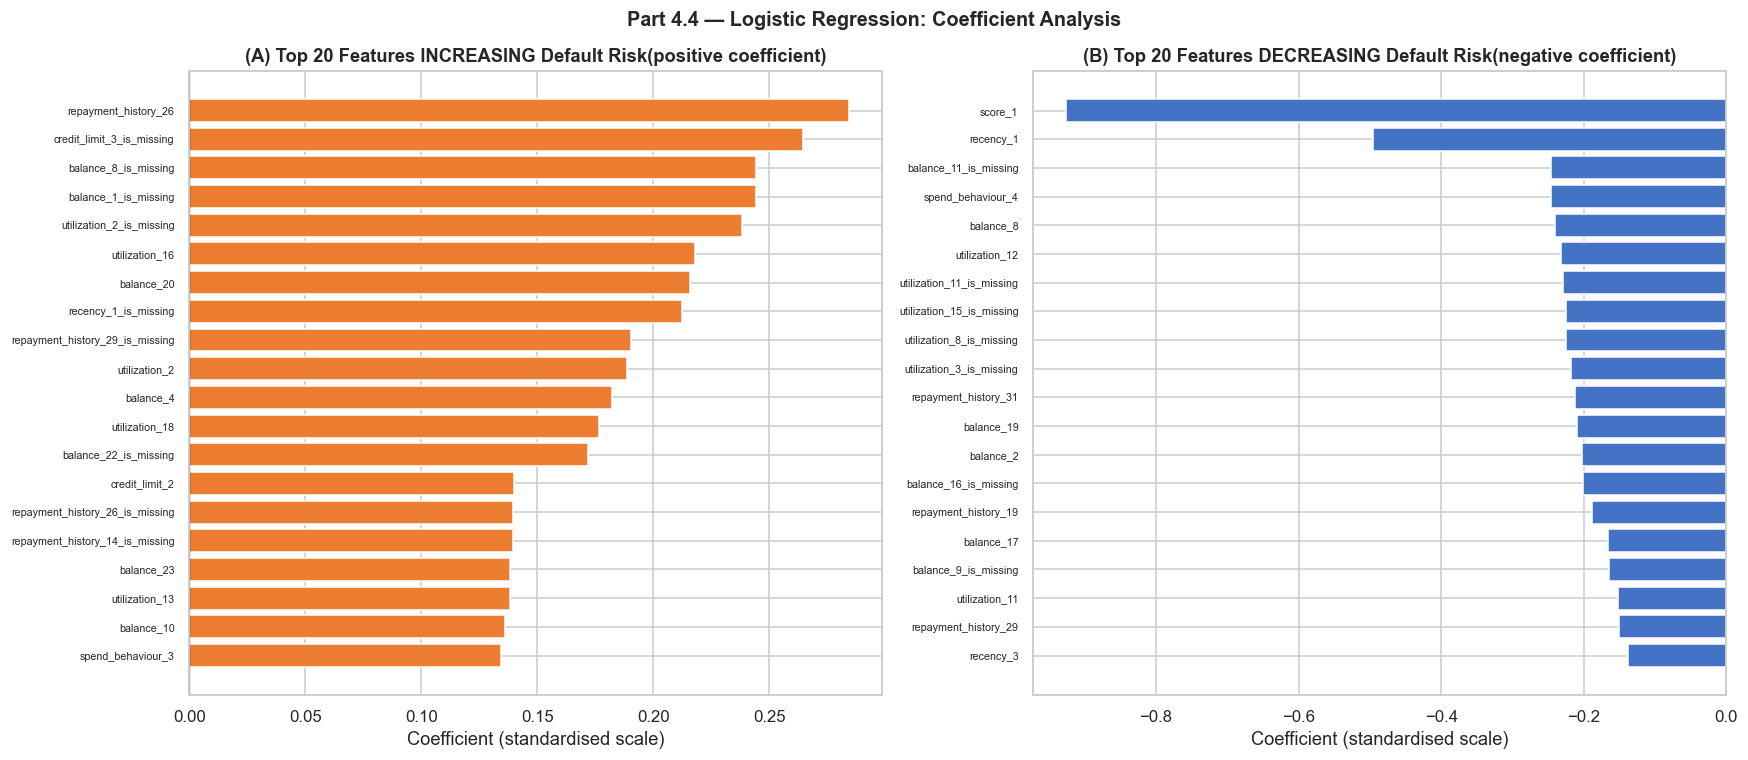


Interpretation guide:
  Positive coefficient → feature value increases default probability
  Negative coefficient → feature value decreases default probability
  All on standardised scale → magnitude is directly comparable


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Part 4.4 — Logistic Regression: Coefficient Analysis",
             fontsize=13, fontweight="bold")

# (A) Top 20 positive coefficients (increase default risk)
ax = axes[0]
top_pos = coef_df[coef_df["coefficient"] > 0].head(20).sort_values("coefficient")
ax.barh(top_pos["feature"], top_pos["coefficient"],
        color=ORANGE, edgecolor="white")
ax.set_title("(A) Top 20 Features INCREASING Default Risk(positive coefficient)",
             fontweight="bold")
ax.set_xlabel("Coefficient (standardised scale)")
ax.axvline(0, color="black", lw=0.8)
ax.tick_params(axis="y", labelsize=7)

# (B) Top 20 negative coefficients (decrease default risk)
ax = axes[1]
top_neg = coef_df[coef_df["coefficient"] < 0].head(20).sort_values("coefficient", ascending=False)
ax.barh(top_neg["feature"], top_neg["coefficient"],
        color=BLUE, edgecolor="white")
ax.set_title("(B) Top 20 Features DECREASING Default Risk(negative coefficient)",
             fontweight="bold")
ax.set_xlabel("Coefficient (standardised scale)")
ax.axvline(0, color="black", lw=0.8)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

print()
print("Interpretation guide:")
print("  Positive coefficient → feature value increases default probability")
print("  Negative coefficient → feature value decreases default probability")
print("  All on standardised scale → magnitude is directly comparable")

## 10 — Cross-Validation Stability

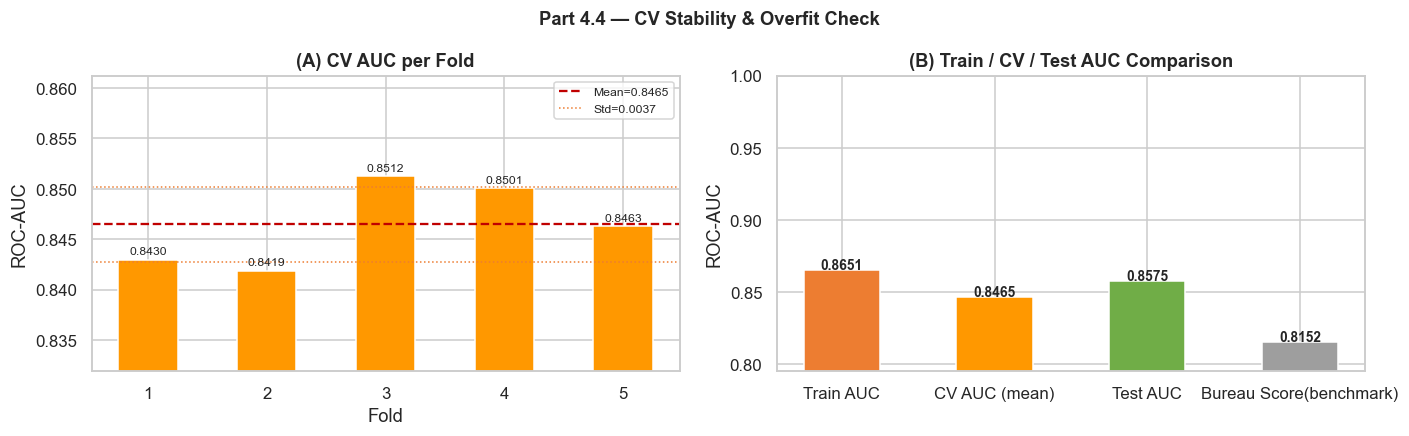

Overfit gap (train AUC - CV mean AUC): +0.0186
  < 0.02 = healthy  |  0.02-0.05 = mild overfit  |  > 0.05 = overfit


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Part 4.4 — CV Stability & Overfit Check", fontsize=12, fontweight="bold")

# (A) CV AUC per fold
ax = axes[0]
ax.bar(range(1, 6), cv_scores, color=MODEL_COLOR, edgecolor="white", width=0.5)
ax.axhline(cv_scores.mean(), color=RED, linestyle="--", lw=1.5,
           label=f"Mean={cv_scores.mean():.4f}")
ax.axhline(cv_scores.mean() - cv_scores.std(), color=ORANGE, linestyle=":", lw=1)
ax.axhline(cv_scores.mean() + cv_scores.std(), color=ORANGE, linestyle=":", lw=1,
           label=f"Std={cv_scores.std():.4f}")
ax.set_title("(A) CV AUC per Fold", fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("ROC-AUC")
ax.set_xticks(range(1, 6))
ax.set_ylim(cv_scores.min() - 0.01, cv_scores.max() + 0.01)
ax.legend(fontsize=8)
for i, s in enumerate(cv_scores, 1):
    ax.text(i, s + 0.0005, f"{s:.4f}", ha="center", fontsize=8)

# (B) Train / CV / Test AUC comparison
ax = axes[1]
labels = ["Train AUC", "CV AUC (mean)", "Test AUC", "Bureau Score(benchmark)"]
values = [train_auc, cv_scores.mean(), test_auc, bureau_auc]
colors = [ORANGE, MODEL_COLOR, GREEN, GRAY]
bars   = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)
ax.set_ylim(min(values) - 0.02, 1.0)
ax.set_title("(B) Train / CV / Test AUC Comparison", fontweight="bold")
ax.set_ylabel("ROC-AUC")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Overfit gap (train AUC - CV mean AUC): {train_auc - cv_scores.mean():+.4f}")
print("  < 0.02 = healthy  |  0.02-0.05 = mild overfit  |  > 0.05 = overfit")

---
## 11 — Store Result & Save

In [11]:
lr_result = {
    "name"       : MODEL_NAME,
    "color"      : MODEL_COLOR,
    "model"      : lr_pipeline,
    "proba_test" : proba_test,
    "test_auc"   : round(test_auc,          4),
    "test_ap"    : round(test_ap,           4),
    "gini"       : round(gini,              4),
    "ks"         : round(ks_val,            4),
    "ks_thresh"  : round(ks_thresh,         4),
    "ks_df"      : ks_df,
    "opt_thresh" : round(opt_thresh,        4),
    "y_pred_opt" : y_pred_opt,
    "cv_mean"    : round(cv_scores.mean(),  4),
    "cv_std"     : round(cv_scores.std(),   4),
    "cv_scores"  : cv_scores.tolist(),
    "train_auc"  : round(train_auc,         4),
    "train_time" : round(train_time,        1),
}

results[MODEL_NAME] = lr_result
joblib.dump(results,    "results_so_far.pkl")
joblib.dump(lr_pipeline,"model_lr.pkl")

print("Stored in results dict and saved to disk:")
print("  results_so_far.pkl  (updated — now contains bureau score + LR)")
print("  model_lr.pkl        (fitted pipeline)")
print()
print("Result summary:")
for k in ["test_auc","test_ap","gini","ks","cv_mean","cv_std","opt_thresh","train_time"]:
    print(f"  {k:<18}: {lr_result[k]}")

Stored in results dict and saved to disk:
  results_so_far.pkl  (updated — now contains bureau score + LR)
  model_lr.pkl        (fitted pipeline)

Result summary:
  test_auc          : 0.8575
  test_ap           : 0.2397
  gini              : 0.7149
  ks                : 0.5938
  cv_mean           : 0.8465
  cv_std            : 0.0037
  opt_thresh        : 0.5463
  train_time        : 39.9


---
## Summary

### Logistic Regression Results

| Metric | Value |
|---|---|
| **Test ROC-AUC** | see output above |
| **Test Avg Precision** | see output above |
| **Gini Coefficient** | see output above |
| **KS Statistic** | see output above |
| **CV AUC (mean ± std)** | see output above |

### Key observations

**Strengths of LR for credit risk:**
- Coefficients directly tell us which features drive default risk and in which direction
- Well-calibrated probabilities (good calibration curve shape)
- Very fast — trains in seconds, CV in < 1 minute
- Interpretable to regulators and business stakeholders

**Limitations:**
- Assumes a **linear** relationship between features and log-odds of default
- Cannot capture feature interactions or non-linear patterns automatically
- May underperform compared to tree models on complex feature relationships

### What to expect from tree models (Parts 4.5 & 4.6)
- Random Forest and GBM can model non-linear patterns and feature interactions
- They typically outperform LR on tabular credit data
- But if the gap is small, the interpretability of LR may still be preferred in production

---
**Next → Part 4.5: Random Forest**